In [13]:
from feature_engineering.create_dtw_distances import create_dtw_distances

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
df = pd.read_csv("Data/extra_features_30_sec.csv")

genres = df['label'].unique()
dist_columns = [f'dist_from_{g}' for g in genres]

dist_data = df[dist_columns + ['label']]

dist_data.head()

,dist_from_blues,dist_from_classical,dist_from_country,dist_from_disco,dist_from_hiphop,dist_from_jazz,dist_from_metal,dist_from_pop,dist_from_reggae,dist_from_rock,label
0,0.625490,1.645667,0.654001,0.743725,1.476752,0.617071,0.984466,0.792486,0.779584,0.594374,blues
1,0.753532,1.168100,0.462971,0.876514,1.726314,0.592014,1.182919,0.967769,0.545847,0.633037,blues
2,0.656100,2.486407,0.865822,0.610506,1.374548,0.658778,0.739447,0.590201,1.089741,0.653238,blues
3,0.785880,2.049481,1.019433,0.790427,1.359265,0.861048,1.242091,1.030923,1.118372,0.819972,blues
4,0.736857,1.187200,0.480247,0.871695,1.691780,0.587864,1.332990,1.042987,0.531365,0.618642,blues


<Axes: xlabel='dist_from_pop', ylabel='Count'>

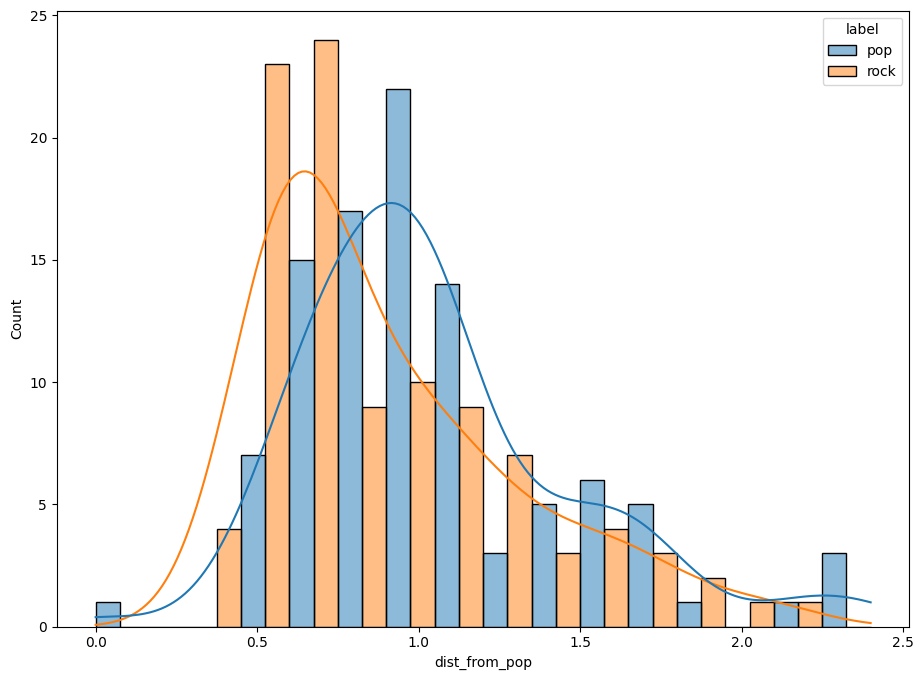

In [3]:
data = dist_data[
    (dist_data['label'] == 'rock') |
    (dist_data['label'] == 'pop')
    ]

plt.figure(figsize=(11, 8))
sns.histplot(data=data, x='dist_from_pop', hue='label', multiple="dodge", kde=True)

In [12]:
X = dist_data.drop('label', axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

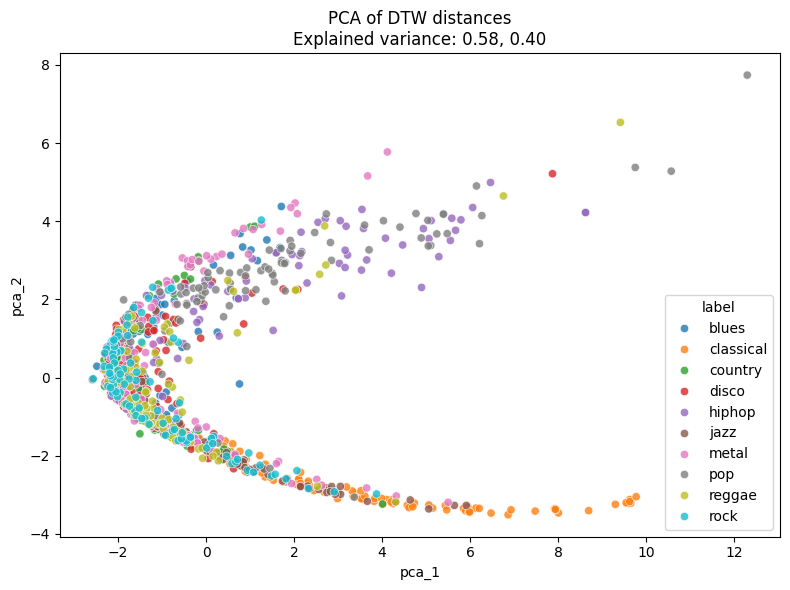

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_data = dist_data.copy()
pca_data["pca_1"] = X_pca[:, 0]
pca_data["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_data,
    x="pca_1",
    y="pca_2",
    hue="label",
    alpha=0.8
)

plt.title(
    f"PCA of DTW distances\n"
    f"Explained variance: "
    f"{pca.explained_variance_ratio_[0]:.2f}, "
    f"{pca.explained_variance_ratio_[1]:.2f}"
)
plt.tight_layout()
plt.show()

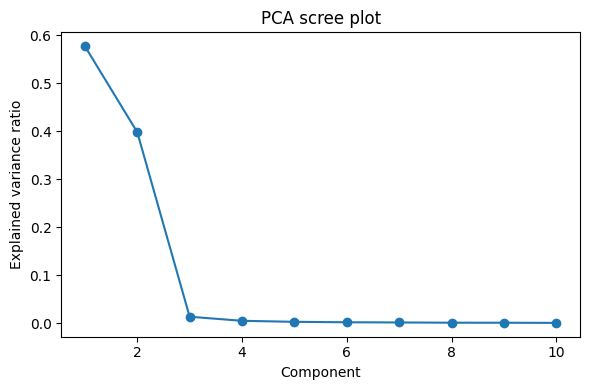

In [20]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.tight_layout()
plt.show()

In [22]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dist_columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [23]:
loadings["PC1"].sort_values(key=np.abs, ascending=False)

dist_from_blues        0.404908
dist_from_rock         0.400736
dist_from_disco        0.400373
dist_from_jazz         0.399292
dist_from_pop          0.357727
dist_from_metal        0.304159
dist_from_country      0.253190
dist_from_hiphop       0.196516
dist_from_reggae       0.180063
dist_from_classical    0.010021
Name: PC1, dtype: float64

In [24]:
loadings["PC2"].sort_values(key=np.abs, ascending=False)

dist_from_classical    0.496206
dist_from_reggae       0.449054
dist_from_hiphop      -0.420975
dist_from_country      0.393918
dist_from_metal       -0.330547
dist_from_pop         -0.244814
dist_from_jazz         0.131455
dist_from_rock         0.128820
dist_from_disco       -0.111998
dist_from_blues        0.064226
Name: PC2, dtype: float64